In [ ]:
from pathlib import Path
import os
import sys

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "src").is_dir()
            and (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate
    raise RuntimeError("Project root was not found. Open this notebook from inside the project folder.")

PROJECT_ROOT = find_project_root()
ROOT = PROJECT_ROOT
root = PROJECT_ROOT
project_root = PROJECT_ROOT

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Working directory:", Path.cwd())


# Classification Pipeline Exercise: Reproducible Growth-Status Modelling

This notebook adapts the classification exercise workflow to the Cane Corso Growth Intelligence project.

The goal is not only to train another classifier. The goal is to practice a complete and reproducible classification workflow:

1. load and inspect the data
2. create dummy baselines
3. build preprocessing pipelines
4. use cross-validation
5. analyze learning curves
6. engineer useful features
7. compare models
8. use safer feature importance analysis
9. perform error analysis
10. run an ablation-style comparison

The task remains educational. The model does **not** provide veterinary diagnosis.


## Mathematical Formulation

### Input vector `X`

This notebook uses the same classification problem, but wraps preprocessing and modelling into a reproducible machine learning pipeline:

```text
X = [numeric_features, categorical_features]
```

Numeric features are scaled and categorical features are encoded before model training:

```text
preprocess(X) = [scaled_numeric_features, one_hot_categorical_features]
```

### Target `y`

The target is the binary growth-status class:

```text
y = growth_status_binary
```

where:

```text
0 = normal_growth
1 = needs_attention
```

### Model function `f(x)`

The full pipeline can be written as:

```text
f(X) = classifier(preprocess(X))
```

For probability-capable models:

```text
f(X) = P(needs_attention | X)
```

### Loss function

Different estimators optimize different internal objectives:

```text
Logistic Regression: log loss with regularization
Decision Tree / Random Forest: impurity reduction
SVM: margin-based objective
Boosting: sequential error correction
```

### Metrics

The pipeline is compared using reproducible evaluation metrics:

```text
cross-validation score
Accuracy
Precision
Recall
F1-score
ROC-AUC
learning curve behavior
permutation importance
```

### Interpretation

The purpose of this notebook is not only to get a score, but to compare modelling strategies and understand which features influence the growth-status decision.

### Limitations

Pipeline results depend on preprocessing choices, feature selection, the constructed target, and the balance between precision and recall. Good cross-validation performance does not mean the model is medically authoritative.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42


## Problem 1 — Load and Inspect the Data

For this exercise, I use the balanced classification sample:

`data/processed/dog_growth_classification_sample.csv`

The target is already prepared:

- `growth_status`: text label
- `growth_status_binary`: numeric binary target

The target was derived from body-condition categories. Therefore, body-condition columns are **not used as model input features**, because that would leak the answer into the model.

For classroom speed and reproducibility, this notebook uses a balanced modelling subset from the processed sample. The full processed classification sample remains available in the project.


In [ ]:
from pathlib import Path
PROJECT_ROOT = next(candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (candidate / "src").is_dir() and (candidate / "data").is_dir())
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

data_path = PROJECT_ROOT / 'data' / 'processed' / 'dog_growth_classification_sample.csv'
raw_df = pd.read_csv(data_path)

print("Full classification sample shape:", raw_df.shape)
print(raw_df["growth_status"].value_counts())
raw_df.head()


In [3]:
# Balanced modelling subset for faster exercise runs.
# This keeps the notebook practical while preserving both classes.
rows_per_class_for_exercise = 2500

df = (
    raw_df
    .groupby("growth_status_binary", group_keys=False)
    .sample(n=rows_per_class_for_exercise, random_state=RANDOM_STATE)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("Modelling subset shape:", df.shape)
print(df["growth_status"].value_counts())
df.head()


Modelling subset shape: (5000, 15)
growth_status
normal_growth      2500
needs_attention    2500
Name: count, dtype: int64


,breed_id,pet_id,gender,visit_age_years,visit_age_months,weight_kg,bcs_recorded,bcs_predicted,bcs_source,growth_status,growth_status_binary,preventive_care_visit,healthy_pet_diagnosis,average_adult_breed_weight_kg,source_type
0,11,985635,M,0.541,6.49,26.671,Normal,NaN,Normal,normal_growth,0,N,N,35.910,real_public_classification_sample
1,11,970585,FS,2.492,29.90,34.428,Heavy,NaN,Heavy,needs_attention,1,N,N,35.910,real_public_classification_sample
2,11,958202,F,2.048,24.58,27.987,NaN,Thin,Thin,needs_attention,1,N,N,35.910,real_public_classification_sample
3,22,2250586,MN,2.317,27.80,12.020,NaN,Normal,Normal,normal_growth,0,N,N,12.569,real_public_classification_sample
4,22,2261781,FS,2.002,24.02,9.435,NaN,Normal,Normal,normal_growth,0,N,N,12.569,real_public_classification_sample


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   breed_id                       5000 non-null   int64  
 1   pet_id                         5000 non-null   int64  
 2   gender                         5000 non-null   str    
 3   visit_age_years                5000 non-null   float64
 4   visit_age_months               5000 non-null   float64
 5   weight_kg                      5000 non-null   float64
 6   bcs_recorded                   3218 non-null   str    
 7   bcs_predicted                  1782 non-null   str    
 8   bcs_source                     5000 non-null   str    
 9   growth_status                  5000 non-null   str    
 10  growth_status_binary           5000 non-null   int64  
 11  preventive_care_visit          5000 non-null   str    
 12  healthy_pet_diagnosis          5000 non-null   str    
 13 

## Experimental Protocol

To keep the exercise reproducible, I define the modelling protocol before comparing models.

The protocol is:

- use the same target: `growth_status_binary`
- exclude leakage columns such as `bcs_recorded`, `bcs_predicted`, `bcs_source`, `growth_status`, and `growth_status_binary`
- use stratified 5-fold cross-validation
- compare models using the same metrics
- keep a separate holdout test split for error analysis

The main metric is F1-score because it balances precision and recall.
Recall is also important because the `needs_attention` class should not be missed in the educational setting.


In [5]:
TARGET_COLUMN = "growth_status_binary"

base_feature_columns = [
    "visit_age_months",
    "weight_kg",
    "average_adult_breed_weight_kg",
    "gender",
    "preventive_care_visit",
    "healthy_pet_diagnosis",
]

y = df[TARGET_COLUMN].astype(int)
X_base = df[base_feature_columns].copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

X_base.head()


,visit_age_months,weight_kg,average_adult_breed_weight_kg,gender,preventive_care_visit,healthy_pet_diagnosis
0,6.49,26.671,35.910,M,N,N
1,29.90,34.428,35.910,FS,N,N
2,24.58,27.987,35.910,F,N,N
3,27.80,12.020,12.569,MN,N,N
4,24.02,9.435,12.569,FS,N,N


## Problem 2 — Dummy Baseline Models

A dummy model is a baseline that does not learn meaningful patterns.

I test two dummy strategies:

- `most_frequent`: always predicts the most common class
- `stratified`: predicts according to the observed class distribution

A real model should perform better than these baselines.


In [6]:
def summarize_cv_results(name, cv_result):
    return {
        "Model": name,
        "Accuracy": cv_result["test_accuracy"].mean(),
        "Precision": cv_result["test_precision"].mean(),
        "Recall": cv_result["test_recall"].mean(),
        "F1-score": cv_result["test_f1"].mean(),
        "AUC": cv_result["test_roc_auc"].mean(),
    }

models_so_far = []

for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    result = cross_validate(dummy, X_base, y, cv=cv, scoring=scoring, n_jobs=1)
    models_so_far.append(summarize_cv_results(f"Dummy ({strategy})", result))

pd.DataFrame(models_so_far)


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Dummy (most_frequent),0.5000,0.000000,0.0000,0.000000,0.5000
1,Dummy (stratified),0.4998,0.499801,0.5028,0.501296,0.4998


## Problem 3 — Data Pipeline

The main pipeline separates numeric and categorical features.

Numeric features:

- missing values are filled with the median
- values are standardized with Z-score scaling

Categorical features:

- missing values are filled with the most frequent category
- categories are one-hot encoded

The first real model is Logistic Regression.


In [7]:
def make_preprocessor(feature_columns):
    numeric_features = [
        column for column in feature_columns
        if column in [
            "visit_age_months",
            "weight_kg",
            "average_adult_breed_weight_kg",
            "weight_to_adult_breed_weight_ratio",
            "age_weight_ratio",
            "growth_pressure_index",
        ]
    ]

    categorical_features = [column for column in feature_columns if column not in numeric_features]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


def make_logistic_pipeline(feature_columns):
    return Pipeline([
        ("preprocessor", make_preprocessor(feature_columns)),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])

logistic_pipeline = make_logistic_pipeline(base_feature_columns)
logistic_cv = cross_validate(logistic_pipeline, X_base, y, cv=cv, scoring=scoring, n_jobs=1)

models_so_far.append(summarize_cv_results("Logistic Pipeline", logistic_cv))
pd.DataFrame(models_so_far)


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Dummy (most_frequent),0.5000,0.000000,0.0000,0.000000,0.500000
1,Dummy (stratified),0.4998,0.499801,0.5028,0.501296,0.499800
2,Logistic Pipeline,0.7908,0.742650,0.8904,0.809746,0.871379


## Problem 4 — Learning Curve

A learning curve shows how model performance changes as the training set becomes larger.

It helps answer questions such as:

- does the model benefit from more data?
- does the model have high bias?
- does the model have high variance?
- should the next improvement be more data, better features, or a different model?


In [8]:
train_sizes, train_scores, validation_scores = learning_curve(
    logistic_pipeline,
    X_base,
    y,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.2, 1.0, 5),
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_f1_mean": train_scores.mean(axis=1),
    "validation_f1_mean": validation_scores.mean(axis=1),
})

learning_curve_df


,train_size,train_f1_mean,validation_f1_mean
0,800,0.813819,0.808115
1,1600,0.808440,0.809553
2,2400,0.812128,0.808276
3,3200,0.812580,0.809152
4,4000,0.810393,0.809746


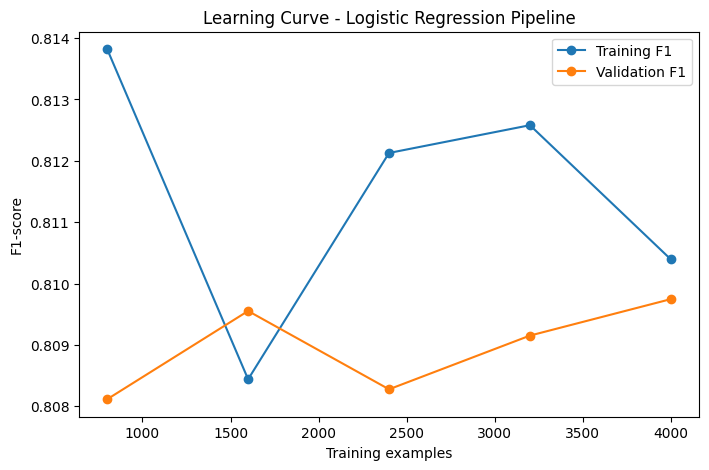

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_f1_mean"], marker="o", label="Training F1")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_f1_mean"], marker="o", label="Validation F1")
plt.xlabel("Training examples")
plt.ylabel("F1-score")
plt.title("Learning Curve - Logistic Regression Pipeline")
plt.legend()
plt.show()


## Problem 5 and 6 — Feature Engineering

The original exercise extracts useful information from columns such as `Cabin` and passenger groups.

In this project, the equivalent is to create growth-related features from age, weight, and expected adult breed weight.

Engineered features:

- `weight_to_adult_breed_weight_ratio`
- `age_weight_ratio`
- `growth_pressure_index`
- `puppy_stage`
- `adult_breed_weight_group`

These features are still educational and should not be interpreted as veterinary diagnosis.


In [10]:
def add_growth_features(dataframe):
    data = dataframe.copy()

    safe_adult_weight = data["average_adult_breed_weight_kg"].replace(0, np.nan)
    safe_age = data["visit_age_months"].replace(0, np.nan)

    data["weight_to_adult_breed_weight_ratio"] = data["weight_kg"] / safe_adult_weight
    data["age_weight_ratio"] = data["weight_kg"] / safe_age
    data["growth_pressure_index"] = data["weight_kg"] / (data["visit_age_months"] + 1)

    data["puppy_stage"] = pd.cut(
        data["visit_age_months"],
        bins=[-0.01, 6, 12, 24, 36],
        labels=["early_puppy", "late_puppy", "young_adult", "adult_transition"],
    ).astype("object")

    data["adult_breed_weight_group"] = pd.cut(
        data["average_adult_breed_weight_kg"],
        bins=[0, 10, 25, 45, 70, 200],
        labels=["small", "medium", "large", "giant", "extra_large"],
    ).astype("object")

    return data

exercise_df = add_growth_features(df)

engineered_feature_columns = base_feature_columns + [
    "weight_to_adult_breed_weight_ratio",
    "age_weight_ratio",
    "growth_pressure_index",
    "puppy_stage",
    "adult_breed_weight_group",
]

X_engineered = exercise_df[engineered_feature_columns].copy()
X_engineered.head()


,visit_age_months,weight_kg,average_adult_breed_weight_kg,gender,preventive_care_visit,healthy_pet_diagnosis,weight_to_adult_breed_weight_ratio,age_weight_ratio,growth_pressure_index,puppy_stage,adult_breed_weight_group
0,6.49,26.671,35.910,M,N,N,0.742718,4.109553,3.560881,late_puppy,large
1,29.90,34.428,35.910,FS,N,N,0.958730,1.151438,1.114175,adult_transition,large
2,24.58,27.987,35.910,F,N,N,0.779365,1.138609,1.094097,adult_transition,large
3,27.80,12.020,12.569,MN,N,N,0.956321,0.432374,0.417361,adult_transition,medium
4,24.02,9.435,12.569,FS,N,N,0.750656,0.392798,0.377098,adult_transition,medium


In [11]:
engineered_logistic_pipeline = make_logistic_pipeline(engineered_feature_columns)
engineered_logistic_cv = cross_validate(
    engineered_logistic_pipeline,
    X_engineered,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

models_so_far.append(summarize_cv_results("Logistic + Engineered Features", engineered_logistic_cv))
pd.DataFrame(models_so_far)


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Dummy (most_frequent),0.5000,0.000000,0.0000,0.000000,0.500000
1,Dummy (stratified),0.4998,0.499801,0.5028,0.501296,0.499800
2,Logistic Pipeline,0.7908,0.742650,0.8904,0.809746,0.871379
3,Logistic + Engineered Features,0.8016,0.756148,0.8908,0.817879,0.881999


## Problem 7 — A Different Model

The exercise asks for another classifier with the same evaluation protocol.

I test two tree-based models:

- Random Forest Classifier
- Gradient Boosting Classifier

They are compared against the Logistic Regression pipeline using the same cross-validation strategy.


In [12]:
def make_random_forest_pipeline(feature_columns):
    return Pipeline([
        ("preprocessor", make_preprocessor(feature_columns)),
        ("classifier", RandomForestClassifier(
            n_estimators=30,
            max_depth=8,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])


def make_gradient_boosting_pipeline(feature_columns):
    return Pipeline([
        ("preprocessor", make_preprocessor(feature_columns)),
        ("classifier", GradientBoostingClassifier(
            n_estimators=60,
            max_depth=2,
            random_state=RANDOM_STATE,
        )),
    ])

forest_pipeline = make_random_forest_pipeline(engineered_feature_columns)
boosting_pipeline = make_gradient_boosting_pipeline(engineered_feature_columns)

forest_cv = cross_validate(forest_pipeline, X_engineered, y, cv=cv, scoring=scoring, n_jobs=1)
boosting_cv = cross_validate(boosting_pipeline, X_engineered, y, cv=cv, scoring=scoring, n_jobs=1)

models_so_far.append(summarize_cv_results("Random Forest + Engineered Features", forest_cv))
models_so_far.append(summarize_cv_results("Gradient Boosting + Engineered Features", boosting_cv))

model_comparison_df = pd.DataFrame(models_so_far)
model_comparison_df.sort_values(by="F1-score", ascending=False)


,Model,Accuracy,Precision,Recall,F1-score,AUC
4,Random Forest + Engineered Features,0.8152,0.767553,0.9044,0.830337,0.900417
5,Gradient Boosting + Engineered Features,0.8086,0.763428,0.8944,0.823722,0.888241
3,Logistic + Engineered Features,0.8016,0.756148,0.8908,0.817879,0.881999
2,Logistic Pipeline,0.7908,0.742650,0.8904,0.809746,0.871379
1,Dummy (stratified),0.4998,0.499801,0.5028,0.501296,0.499800
0,Dummy (most_frequent),0.5000,0.000000,0.0000,0.000000,0.500000


## Problem 8 — Feature Importance

Tree-based `feature_importances_` can be misleading, especially with correlated or high-cardinality features.

For this exercise, I use **permutation importance** on a holdout test split. This answers a more practical question:

> How much does model performance drop when one input feature is shuffled?

This is still model-specific and data-specific, so it should be interpreted carefully.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

candidate_models = {
    "Logistic + Engineered Features": engineered_logistic_pipeline,
    "Random Forest + Engineered Features": forest_pipeline,
    "Gradient Boosting + Engineered Features": boosting_pipeline,
}

holdout_results = []
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    holdout_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-score": f1_score(y_test, predictions, zero_division=0),
        "AUC": roc_auc_score(y_test, probabilities),
    })

holdout_results_df = pd.DataFrame(holdout_results).sort_values(by="F1-score", ascending=False)
holdout_results_df


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic + Engineered Features,0.8112,0.766804,0.8944,0.825702,0.892311
2,Gradient Boosting + Engineered Features,0.8104,0.765027,0.8960,0.825350,0.896093
1,Random Forest + Engineered Features,0.8104,0.766484,0.8928,0.824834,0.907994


In [14]:
best_model_name = holdout_results_df.iloc[0]["Model"]
best_model = candidate_models[best_model_name]

importance_subset = X_test.sample(n=min(800, len(X_test)), random_state=RANDOM_STATE)
importance_y = y_test.loc[importance_subset.index]

importance_result = permutation_importance(
    best_model,
    importance_subset,
    importance_y,
    scoring="f1",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_importance_df = pd.DataFrame({
    "Feature": importance_subset.columns,
    "Importance mean": importance_result.importances_mean,
    "Importance std": importance_result.importances_std,
}).sort_values(by="Importance mean", ascending=False)

best_model_name, permutation_importance_df


('Logistic + Engineered Features',
                                Feature  Importance mean  Importance std
 1                            weight_kg         0.209485        0.007029
 2        average_adult_breed_weight_kg         0.111513        0.010579
 8                growth_pressure_index         0.103783        0.006413
 10            adult_breed_weight_group         0.048436        0.007392
 0                     visit_age_months         0.031654        0.003308
 7                     age_weight_ratio         0.028564        0.003609
 9                          puppy_stage         0.010032        0.002612
 5                healthy_pet_diagnosis         0.009753        0.001345
 3                               gender         0.006739        0.001659
 4                preventive_care_visit        -0.000759        0.001781
 6   weight_to_adult_breed_weight_ratio        -0.004784        0.000617)

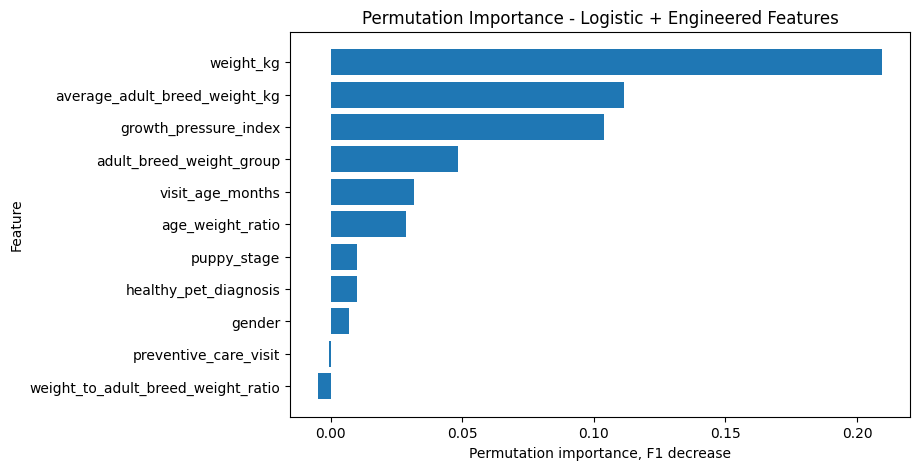

In [15]:
plt.figure(figsize=(8, 5))
plt.barh(
    permutation_importance_df["Feature"],
    permutation_importance_df["Importance mean"],
)
plt.xlabel("Permutation importance, F1 decrease")
plt.ylabel("Feature")
plt.title(f"Permutation Importance - {best_model_name}")
plt.gca().invert_yaxis()
plt.show()


## Problems 9 and 10 — Error Analysis

After selecting a strong candidate model, I inspect its mistakes.

The goal is not only to report a score, but to understand model behavior:

- where does the model make mistakes?
- are false positives and false negatives different?
- are some age groups harder?
- are there confidently wrong predictions?


In [16]:
best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(X_test)[:, 1]

error_analysis_df = X_test.copy()
error_analysis_df["actual"] = y_test.values
error_analysis_df["predicted"] = best_predictions
error_analysis_df["needs_attention_probability"] = best_probabilities
error_analysis_df["is_error"] = error_analysis_df["actual"] != error_analysis_df["predicted"]

error_analysis_df["error_type"] = np.select(
    [
        (error_analysis_df["actual"] == 0) & (error_analysis_df["predicted"] == 1),
        (error_analysis_df["actual"] == 1) & (error_analysis_df["predicted"] == 0),
    ],
    ["false_positive", "false_negative"],
    default="correct",
)

error_analysis_df["error_type"].value_counts()


error_type
correct           1014
false_positive     170
false_negative      66
Name: count, dtype: int64

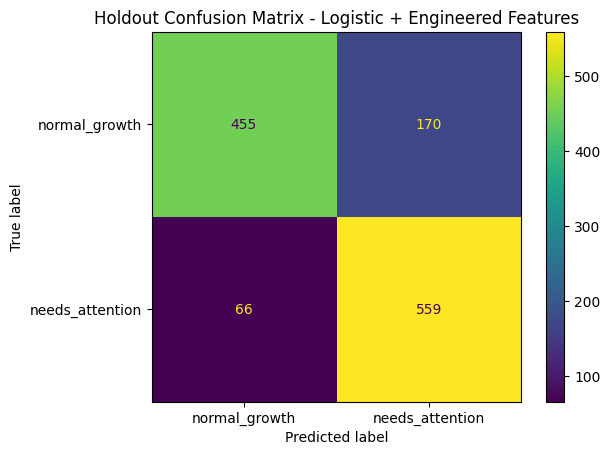

                 precision    recall  f1-score   support

  normal_growth       0.87      0.73      0.79       625
needs_attention       0.77      0.89      0.83       625

       accuracy                           0.81      1250
      macro avg       0.82      0.81      0.81      1250
   weighted avg       0.82      0.81      0.81      1250



In [17]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, best_predictions),
    display_labels=["normal_growth", "needs_attention"],
).plot()
plt.title(f"Holdout Confusion Matrix - {best_model_name}")
plt.show()

print(classification_report(
    y_test,
    best_predictions,
    target_names=["normal_growth", "needs_attention"],
    zero_division=0,
))


In [18]:
error_by_stage = (
    error_analysis_df
    .groupby("puppy_stage", dropna=False)["is_error"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("error_rate")
)

error_by_stage


,error_rate
puppy_stage,
late_puppy,0.406250
young_adult,0.275109
early_puppy,0.273224
adult_transition,0.113208


In [19]:
confident_wrong = error_analysis_df[
    (error_analysis_df["is_error"])
    & (
        (error_analysis_df["needs_attention_probability"] >= 0.8)
        | (error_analysis_df["needs_attention_probability"] <= 0.2)
    )
].sort_values(by="needs_attention_probability", ascending=False)

confident_wrong.head(10)


,visit_age_months,weight_kg,average_adult_breed_weight_kg,gender,preventive_care_visit,healthy_pet_diagnosis,weight_to_adult_breed_weight_ratio,age_weight_ratio,growth_pressure_index,puppy_stage,adult_breed_weight_group,actual,predicted,needs_attention_probability,is_error,error_type
2317,24.55,46.629,35.91,M,Y,N,1.298496,1.899348,1.825010,adult_transition,large,0,1,0.919257,True,false_positive
1696,21.00,47.400,35.91,M,Y,N,1.319967,2.257143,2.154545,young_adult,large,0,1,0.907892,True,false_positive
911,35.75,50.485,35.91,MN,N,N,1.405876,1.412168,1.373741,adult_transition,large,0,1,0.903124,True,false_positive
4901,22.99,44.906,35.91,M,Y,N,1.250515,1.953284,1.871863,young_adult,large,0,1,0.902222,True,false_positive
4639,28.32,47.673,35.91,MN,Y,N,1.327569,1.683369,1.625955,adult_transition,large,0,1,0.896881,True,false_positive
1329,22.46,50.349,35.91,MN,Y,N,1.402089,2.241719,2.146164,young_adult,large,0,1,0.894815,True,false_positive
1799,31.63,44.452,35.91,FS,N,N,1.237872,1.405375,1.362305,adult_transition,large,0,1,0.869609,True,false_positive
3502,34.06,42.910,35.91,FS,Y,N,1.194932,1.259836,1.223902,adult_transition,large,0,1,0.868990,True,false_positive
2234,28.97,40.234,35.91,M,N,N,1.120412,1.388816,1.342476,adult_transition,large,0,1,0.866868,True,false_positive
355,17.72,50.349,35.91,MN,Y,N,1.402089,2.841366,2.689583,young_adult,large,0,1,0.854239,True,false_positive


## Problem 11 — Ablation Study

An ablation study compares feature groups under the same protocol.

This helps answer which groups add useful information.

In this project, I compare:

- numeric growth features only
- numeric + categorical base features
- ratio features only
- full engineered feature set

For each feature group, I test Logistic Regression and Random Forest.


In [20]:
feature_group_map = {
    "numeric_base": [
        "visit_age_months",
        "weight_kg",
        "average_adult_breed_weight_kg",
    ],
    "numeric_plus_categorical_base": base_feature_columns,
    "ratio_features_only": [
        "weight_to_adult_breed_weight_ratio",
        "age_weight_ratio",
        "growth_pressure_index",
    ],
    "full_engineered": engineered_feature_columns,
}

ablation_results = []

for group_name, feature_columns in feature_group_map.items():
    X_group = exercise_df[feature_columns].copy()

    model_factories = {
        "Logistic Regression": make_logistic_pipeline,
        "Random Forest": make_random_forest_pipeline,
    }

    for model_name, factory in model_factories.items():
        model = factory(feature_columns)
        result = cross_validate(model, X_group, y, cv=cv, scoring=scoring, n_jobs=1)
        summary = summarize_cv_results(f"{model_name} | {group_name}", result)
        summary["Feature group"] = group_name
        summary["Base model"] = model_name
        ablation_results.append(summary)

ablation_df = pd.DataFrame(ablation_results)
ablation_df.sort_values(by="F1-score", ascending=False)


,Model,Accuracy,Precision,Recall,F1-score,AUC,Feature group,Base model
7,Random Forest | full_engineered,0.8152,0.767553,0.9044,0.830337,0.900417,full_engineered,Random Forest
3,Random Forest | numeric_plus_categorical_base,0.8112,0.765939,0.8964,0.826005,0.895919,numeric_plus_categorical_base,Random Forest
6,Logistic Regression | full_engineered,0.8016,0.756148,0.8908,0.817879,0.881999,full_engineered,Logistic Regression
1,Random Forest | numeric_base,0.7982,0.749493,0.8960,0.816164,0.880384,numeric_base,Random Forest
0,Logistic Regression | numeric_base,0.7934,0.742334,0.8988,0.813089,0.862630,numeric_base,Logistic Regression
2,Logistic Regression | numeric_plus_categorical...,0.7908,0.742650,0.8904,0.809746,0.871379,numeric_plus_categorical_base,Logistic Regression
5,Random Forest | ratio_features_only,0.7878,0.737060,0.8952,0.808413,0.869781,ratio_features_only,Random Forest
4,Logistic Regression | ratio_features_only,0.7302,0.726310,0.7388,0.732374,0.769199,ratio_features_only,Logistic Regression


## Final Exercise Report

This notebook extends the first classification notebook with a more complete machine-learning workflow.

Main conclusions:

- Dummy baselines are necessary because they show the minimum performance a real model should beat.
- Pipelines make preprocessing reproducible and reduce the risk of accidental data leakage.
- Cross-validation gives a more stable estimate than a single train/test split.
- Feature engineering can improve the representation of growth-related patterns, but it must be justified.
- Permutation importance is safer than blindly trusting tree impurity-based importances.
- Error analysis is essential because a single score does not explain where the model fails.
- Ablation helps compare feature groups and shows which information is useful.

The work remains educational and does not provide veterinary diagnosis.
